### Análisis y Procesamiento de Señales
# Trabajo Práctico N°0 
### Paulina Benito

En el siguiente informe se comparará el comportamiento de una señal senoidal y una señal cuadrada frente a una variación de frecuencias. 

Como primer paso importo las librerias necesarias para las funciones del código.

In [2]:
import matplotlib.pyplot as plt 
import numpy as np 
from scipy import signal

Luego hago una serie de definiciones, entre ellas la función a generar y sus parámetros corrspondientes.

In [3]:
def funcion_sen( vmax , dc, ff , ph, nn,  fs) : 
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)
    return (tt,xx)

N= 1000 #Hz
fs= 1000 #Muestras 
ts= 1/fs 
ph=0
nn=N   
vmax = 1.5
dc= 0

def funcion_cuadrada(vmax, dc, ff, ph, nn, fs):

    ts = 1/fs
    tt = np.arange(0, nn) * ts

    yy = dc + vmax * signal.square(2*np.pi*ff*tt + ph)

    return tt, yy

A continuación se irá modificando las frecuencias para poder estudiar el comportamiento de la señal. 

<function matplotlib.pyplot.show(close=None, block=None)>

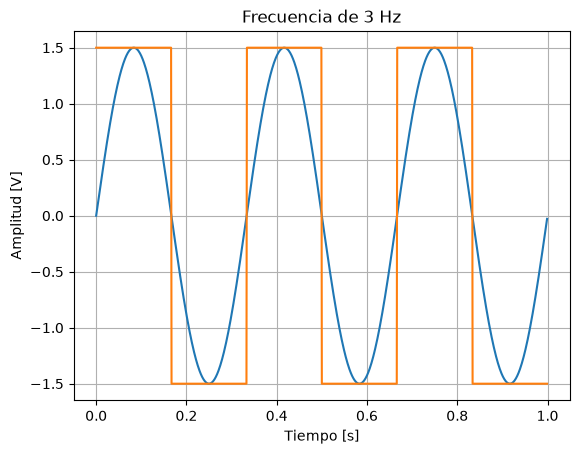

In [33]:
ff= 3
tt=np.arange(0,nn) *ts 
tt, xx = mi_funcion_sen( vmax , dc , ff , ph, nn,  fs)
tt, yy = mi_funcion_cuadrada(vmax, dc, ff, ph, nn, fs)


plt.figure()
plt.title("Comparación en frecuencia de 3 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.plot(tt, xx)
plt.plot(tt,yy)
plt.show

Como la frecuencia fue definida en 3Hz, el gráfico muestra las 3 ciclos por segundo en ambas señales. 

Ahora modifico la frecuencia a 100Hz.

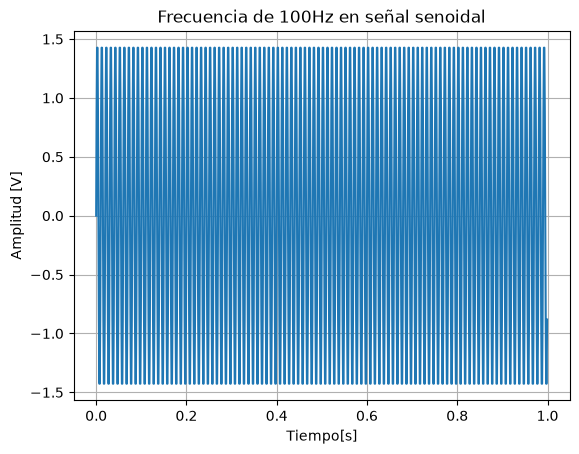

In [41]:
ff2 = 100
tt2, xx2 = funcion_sen(vmax, dc, ff2, ph, nn, fs)

#Gráfico 2
plt.figure()
plt.title("Frecuencia de 100Hz en señal senoidal")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo[s]")
plt.plot(tt2, xx2)
plt.grid()
plt.show()

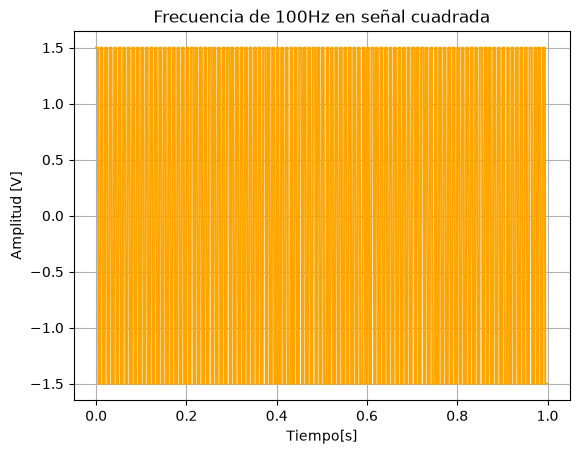

In [38]:
ff2 = 100
tt2, yy2 = funcion_cuadrada(vmax, dc, ff2, ph, nn, fs)
plt.figure()
plt.title("Frecuencia de 100Hz en señal cuadrada")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo[s]")
plt.plot(tt2, yy2, color="orange")
plt.grid()
plt.show()

Los gráficos se ven más densos porque al aumentar la frecuencia de la señal entran más períodos en el mismo segundo. 

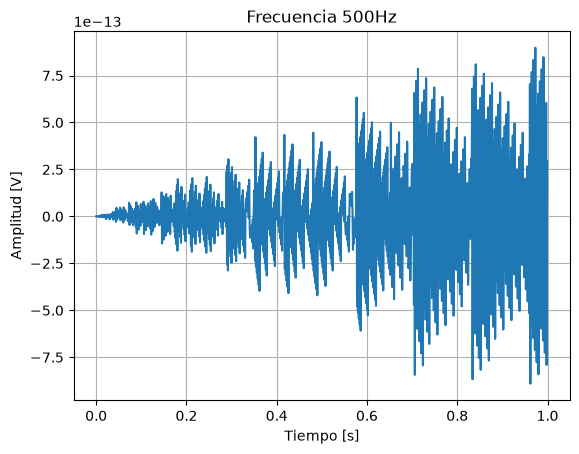

In [23]:
ff3 = 500
tt3, xx3 = funcion_sen(vmax, dc, ff3, ph, nn, fs)
                                  
plt.figure()
plt.title("Frecuencia 500Hz")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.plot(tt3, xx3)
plt.grid()
plt.show()

Como la frecuencia de muestreo es fs=1000Hz, al implementar una frecuencia de 500Hz estanos tomando el valor exacto de Nyquist (fs/2). Esto indica que las muestras deberían ser 0. Por ende, este gráfico no muestra una señal sino que errores computacional. 

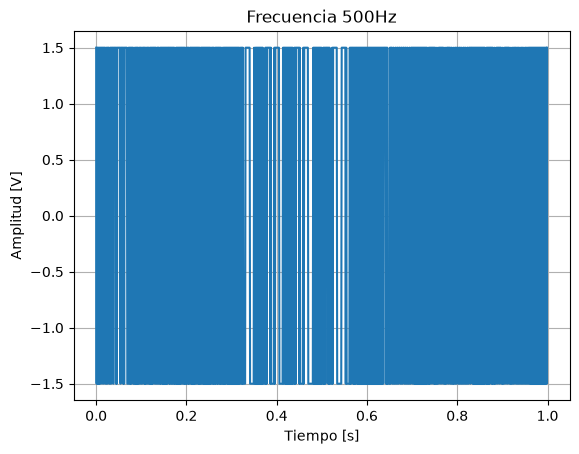

In [42]:
ff3 = 500
tt, yy3 = funcion_cuadrada(vmax, dc, ff3, ph, nn, fs)                                
plt.figure()
plt.title("Frecuencia 500Hz")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.plot(tt3, yy3)
plt.grid()
plt.show()

En este caso pasa algo parecido, como estamos en exactamente en la frecuencia de Nyquist, se tienen dos muestras lo que hace que la representación de la señal sea poco confiable. 

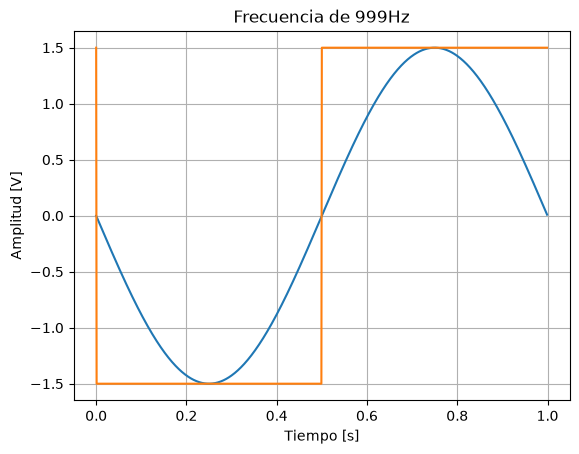

In [44]:
ff4 = 999
tt4, xx4 = funcion_sen(vmax, dc, ff4, ph, nn, fs)
tt, yy4 = funcion_cuadrada(vmax, dc, ff4, ph, nn, fs) 
#Gráfico 4
plt.figure()
plt.title("Frecuencia de 999Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.plot(tt4, xx4)
plt.plot(tt,yy4)
plt.grid()
plt.show()

Como ahora la frecuencia es 999Hz, es decir, 1 Hz menos que la fs, no se cumple la condición de Nyquist y aparece el aliasing. El gráfico muestra ambas señales de 1 Hz invertidas en fase debido a que 999 Hz es equivalente a 1000-1 Hz respecto a la frecuencia de muestreo.

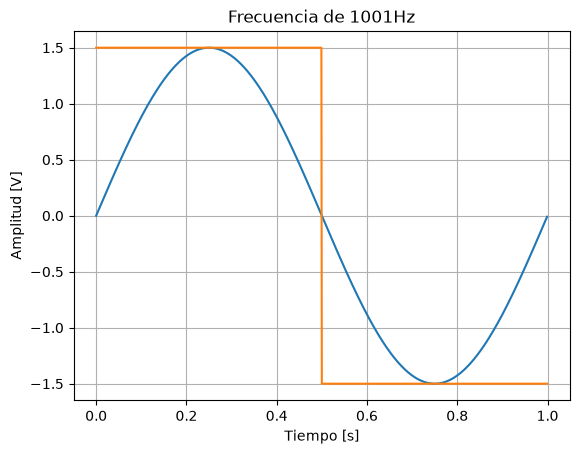

In [45]:
ff5=1001
tt5, xx5 = funcion_sen(vmax, dc, ff5 , ph, nn, fs)
tt, yy5 = funcion_cuadrada(vmax, dc, ff5, ph, nn, fs)
#Gráfico 5                                
plt.figure()
plt.title("Frecuencia de 1001Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.plot(tt5,xx5)
plt.plot(tt,yy5)
plt.grid()
plt.show()


En este caso pasa algo parecido al anterior pero con fase invertida debido a que las muestras son equivalentes a las de una señal de 1Hz debido al aliasing. 

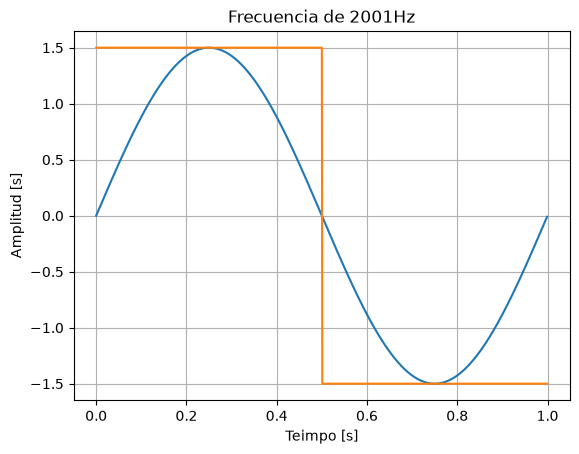

In [47]:
ff6=2001
tt6, xx6 = funcion_sen(vmax, dc, ff6 , ph, nn, fs)
tt, yy6 = funcion_cuadrada(vmax, dc, ff6, ph, nn, fs)
#Gráfico 6                                
plt.figure()
plt.title("Frecuencia de 2001Hz")
plt.ylabel("Amplitud [s]")
plt.xlabel("Teimpo [s]")
plt.grid()
plt.plot(tt6,xx6)
plt.plot(tt,yy6)
plt.show()

Al igual que en los casos de 999 Hz y 1001 Hz, acá también aparece aliasing porque no se cumple Nyquist. La diferencia es que 2001 Hz equivale a 2fs+1, por lo que las muestras vuelven a comportarse como una señal aparente de 1 Hz.

Para concluir, mientras se cumple la condición de Nyquist, la señal puede representarse correctamente. En cambio, al acercarse o superar el límite de Nyquist aparecen problemas de muestreo y aliasing, generando señales aparentes de menor frecuencia o representaciones poco confiables.